# Milestone 4 solution:  Improve the machine learning model
 
## Objective
 
- Iteratively improve the model accuracy: use external datasets, work
  on feature extraction, and tune hyper-parameters.
 
## Requirements
 
Install the Python package that we have created in our previous milestone, which contains some of the useful functions,

In [41]:
! pip install --upgrade https://public-sym.s3-eu-west-1.amazonaws.com/LP-safety-US-cities/safety-events-cities-1.0.0.tar.gz

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
  Created wheel for safety-events-cities: filename=safety_events_cities-1.0.0-py3-none-any.whl size=2975 sha256=21d7c816f2e0a613fbb13d2805ff84192287de27451b2d11411eeda9230d8488
  Stored in directory: /home/rth/.cache/pip/wheels/31/3b/3a/02c5de71c1358088b9a2e6d6c1793ea657f179a14d3a6ec554
Successfully built safety-events-cities
  Attempting uninstall: safety-events-cities
    Found existing installation: safety-events-cities 1.0.0
    Uninstalling safety-events-cities-1.0.0:
      Successfully uninstalled safety-events-cities-1.0.0


<IPython.core.display.Javascript object>

This solution also requires the `holidays` package,

In [1]:
!pip install holidays

     |████████████████████████████████| 120 kB 20.1 MB/s eta 0:00:01
  Using cached PyMeeus-0.3.7-py3-none-any.whl
  Using cached pytz-2019.3-py2.py3-none-any.whl (509 kB)
  Using cached korean_lunar_calendar-0.2.1-py3-none-any.whl (8.0 kB)
  Created wheel for holidays: filename=holidays-0.10.4-py3-none-any.whl size=124775 sha256=124f4df66280587ad39b3680503338ba76bac168b334e7051195dda5d9105007
  Stored in directory: /home/rth/.cache/pip/wheels/ef/70/9e/34eb54fef725c637dc8ce508e323021fd709354951abe622c4
Successfully built holidays
  Attempting uninstall: pytz
    Found existing installation: pytz 2020.5
    Uninstalling pytz-2020.5:
      Successfully uninstalled pytz-2020.5


In [8]:
# this plugin requires to run "pip install nb-black"
%load_ext nb_black

# Reload modules automatically when importing code
%load_ext autoreload
%autoreload 2

<IPython.core.display.Javascript object>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

We start by list most frequent categories, for future reference,

In [2]:
x = pd.read_parquet("../data/safety-SanFrancisco-2.parquet")

In [3]:
x["category"].value_counts().head(10)

Street and Sidewalk Cleaning      965968
Potentially Life-Threatening      676296
Non Life-threatening              349634
Alarm                             326893
Graffiti                          296927
Encampments                       239275
Parking Enforcement               153902
Abandoned Vehicle                 124820
MUNI Feedback                      90754
General Request - PUBLIC WORKS     74203
Name: category, dtype: int64

We use the `load_data` function created in the previous milestone, that filters the data to 2016-2019, select one category, and count the number of events per neighborhood for each day.

In [11]:
from safety_events_cities.milestone3 import load_data

df = load_data(
    "../data/safety-SanFrancisco-2.parquet",
    category="Street and Sidewalk Cleaning",
    years=[2016, 2017, 2018, 2019],
    freq="6H",
)

df.head()

,dateTime,neighborhood,count
0,2016-01-01 00:00:00,Mission,2
1,2016-01-01 00:00:00,Nob Hill,1
2,2016-01-01 06:00:00,Ingleside,1
3,2016-01-01 06:00:00,Mission,9
4,2016-01-01 06:00:00,Nob Hill,5


<IPython.core.display.Javascript object>

## 1-2. Using external data

To enrich the features available for modeling, we will add two externals dataset, in particular holiday and weather data.

###  1.1 Taking into account holidays

Federal US holidays as well as local state holidays for California can be obtained with the 
[holidays](https://pypi.org/project/holidays/) package

In [13]:
import holidays

us_ca_holidays = holidays.UnitedStates(state="CA", years=range(2010, 2025))

<IPython.core.display.Javascript object>

We create a new boolean column to indicate whether a given date is a holiday,

In [14]:
df["is_holiday"] = df["dateTime"].dt.date.isin(us_ca_holidays.keys())

<IPython.core.display.Javascript object>

In [15]:
df["is_holiday"].sum()

985

<IPython.core.display.Javascript object>

In [16]:
df.groupby(["neighborhood", "is_holiday"])["count"].mean()

neighborhood  is_holiday
Ingleside     False          9.701782
              True           8.870270
Mission       False         20.185226
              True          17.085714
Nob Hill      False         12.287092
              True          11.517588
SoMa          False         18.683566
              True          14.271357
Tenderloin    False         11.766969
              True           9.500000
Name: count, dtype: float64

<IPython.core.display.Javascript object>

To approximately evaluate the impact of the added variable, we can compare the mean number of events per day on a holiday and a non holiday day. There are 7-25% fewer events of the considered type during holidays.

In [17]:
from datetime import timedelta

df["is_holiday_eve"] = df["dateTime"].dt.date.isin(
    [date - timedelta(days=1) for date in us_ca_holidays.keys()]
)

<IPython.core.display.Javascript object>

Similarly we create an new boolean variable for dates corresponding to holiday eves.

In [18]:
df.groupby(["neighborhood", "is_holiday_eve"])["count"].mean()

neighborhood  is_holiday_eve
Ingleside     False              9.731864
              True               8.085106
Mission       False             20.204442
              True              16.633803
Nob Hill      False             12.311762
              True              10.873096
SoMa          False             18.705916
              True              13.783251
Tenderloin    False             11.785484
              True               9.091371
Name: count, dtype: float64

<IPython.core.display.Javascript object>

### 1.2 Weather data

We next load the [weather data](https://docs.opendata.aws/noaa-ghcn-pds/readme.html) from the NOAA Global Historical Climatology Network. The data is already with daily periodicity, however the values for different sensors are encoded row wise.

In [19]:
import pandas as pd

df_w = pd.read_parquet("../data/weather-data-SF-Nyc-Seattle-2015-2020.parquet")
df_w["date"] = pd.to_datetime(df_w["date"], format="%Y%m%d")
mask = df_w["station"] == "USW00023234"  # Filter to San Francicso station

df_w = df_w[mask]
df_w.head()

,station,date,field,value
14,USW00023234,2015-01-01,TMAX,128
15,USW00023234,2015-01-01,TMIN,44
16,USW00023234,2015-01-01,PRCP,0
17,USW00023234,2015-01-01,AWND,38
18,USW00023234,2015-01-01,TAVG,97


<IPython.core.display.Javascript object>

We use `set_index` followed by `unstack` pandas methods, to create a pivot table where each field has a separate column. Another important step is that we need to fill missing values, using either previous or following values.

In [20]:
# make a pivot table
df_w = df_w.set_index(["date", "field"])["value"].unstack(-1)
# Fill NA first by forward filling missing values, then by backward filling.
df_w = df_w.fillna(method="ffill").fillna(method="bfill")

df_w.head()

field,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2
date,,,,,,,
2015-01-01,38.0,0.0,0.0,97.0,128.0,44.0,89.0
2015-01-02,7.0,0.0,0.0,77.0,111.0,33.0,31.0
2015-01-03,7.0,0.0,0.0,77.0,122.0,33.0,31.0
2015-01-04,9.0,0.0,0.0,86.0,128.0,50.0,63.0
2015-01-05,11.0,0.0,0.0,98.0,150.0,61.0,31.0


<IPython.core.display.Javascript object>

For instance, let's visualize the mean daily temperature,

<AxesSubplot:xlabel='date'>

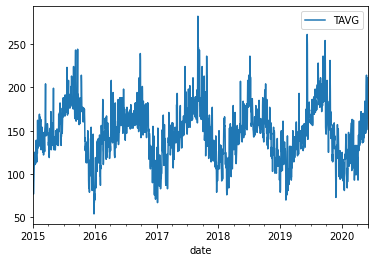

<IPython.core.display.Javascript object>

In [21]:
df_w.reset_index().plot(y="TAVG", x="date")

We create a function to merge the weather information with the original data,

In [22]:
def add_weather(df):
    df["date"] = df["dateTime"].dt.date
    # we need to create a new column with date
    df_w["date_merge"] = df_w.index.date
    res = df.merge(df_w, left_on="date", right_on="date_merge", how="left")
    del res["date_merge"]
    return res


df_tmp = add_weather(df.copy())
df_tmp.head()

,dateTime,neighborhood,count,is_holiday,is_holiday_eve,date,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2
0,2016-01-01 00:00:00,Mission,2,True,False,2016-01-01,39.0,0.0,0.0,70.0,94.0,28.0,76.0
1,2016-01-01 00:00:00,Nob Hill,1,True,False,2016-01-01,39.0,0.0,0.0,70.0,94.0,28.0,76.0
2,2016-01-01 06:00:00,Ingleside,1,True,False,2016-01-01,39.0,0.0,0.0,70.0,94.0,28.0,76.0
3,2016-01-01 06:00:00,Mission,9,True,False,2016-01-01,39.0,0.0,0.0,70.0,94.0,28.0,76.0
4,2016-01-01 06:00:00,Nob Hill,5,True,False,2016-01-01,39.0,0.0,0.0,70.0,94.0,28.0,76.0


<IPython.core.display.Javascript object>

To measure the relevance of added features on the target variable, we can compute the Pearson correlation between them.

In [23]:
columns = ["count", "AWND", "PRCP", "SNWD", "TAVG", "TMAX", "TMIN", "WSF2"]

df_tmp[columns].corr().round(2)

,count,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2
count,1.00,-0.04,-0.06,NaN,0.05,0.06,0.04,-0.04
AWND,-0.04,1.00,0.10,NaN,0.22,0.05,0.32,0.87
PRCP,-0.06,0.10,1.00,NaN,-0.14,-0.23,-0.06,0.19
SNWD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TAVG,0.05,0.22,-0.14,NaN,1.00,0.87,0.89,0.21
TMAX,0.06,0.05,-0.23,NaN,0.87,1.00,0.70,0.11
TMIN,0.04,0.32,-0.06,NaN,0.89,0.70,1.00,0.27
WSF2,-0.04,0.87,0.19,NaN,0.21,0.11,0.27,1.00


<IPython.core.display.Javascript object>

There is no strong linear correlation between weather and the number of events that we are trying to predict. However a non-linear model model, as used in the 

## 3. Gradient boosting model

Gradient boosting decision trees (GBDT) is accurate and effective off-the-shelf algorithm for regression or classification that works well that is suitable to tabular data. Here we will use the histogram based variation included in scikit-learn (`HistGradientBoostingRegressor`) that is inspired by [LightGBM](https://lightgbm.readthedocs.io/en/latest/).

We re-create similar preprocessing pipeline to that of step 2 except for using OrdinalEncoder instead of OneHotEncoder, as tree based models are not suitable for very high dimensional features.

In [24]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df.sort_values("dateTime"), test_size=0.15, shuffle=False
)

<IPython.core.display.Javascript object>

In [25]:
print("Train:", df_train["dateTime"].min(), "-", df_train["dateTime"].max())
print("Test:", df_test["dateTime"].min(), "-", df_test["dateTime"].max())

Train: 2016-01-01 00:00:00 - 2019-05-31 06:00:00
Test: 2019-05-31 12:00:00 - 2019-12-31 18:00:00


<IPython.core.display.Javascript object>

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer
import sklearn
from sklearn.preprocessing import StandardScaler

from safety_events_cities.milestone3 import encode_timestamp

sklearn.set_config(display="diagram")


def detect_holidays(df):
    us_ca_holidays = holidays.UnitedStates(state="CA", years=range(2010, 2025))
    df["is_holiday"] = df["dateTime"].dt.date.isin(us_ca_holidays.keys())
    df["is_holiday_eve"] = df["dateTime"].dt.date.isin(
        [date - timedelta(days=1) for date in us_ca_holidays.keys()]
    )
    return df


column_transformer_ord = ColumnTransformer(
    [
        (
            "cat",
            OrdinalEncoder(),
            ["neighborhood", "year"],
        ),
        (
            "passthrough",
            "passthrough",
            [
                "month",
                "day",
                "dayofweek",
                "hour",
                "dayofyear",
                "is_holiday",
                "is_holiday_eve",
            ],
        ),
        (
            "numeric",
            StandardScaler(),
            ["AWND", "PRCP", "TAVG", "TMAX", "TMIN", "WSF2"],
        ),
    ]
)

pipe = make_pipeline(
    FunctionTransformer(encode_timestamp),
    FunctionTransformer(detect_holidays),
    FunctionTransformer(add_weather),
    column_transformer_ord,
)
X_train = pipe.fit_transform(df_train)
X_test = pipe.transform(df_test)

<IPython.core.display.Javascript object>

In [27]:
from sklearn.experimental import enable_hist_gradient_boosting  # noqa

from sklearn.ensemble import HistGradientBoostingRegressor

est_gb = HistGradientBoostingRegressor(
    max_depth=4, loss="poisson", learning_rate=0.05
).fit(
    X_train,
    df_train["count"],
)

<IPython.core.display.Javascript object>

In [28]:
from safety_events_cities.milestone3 import evaluate_model

evaluate_model(est_gb, ["train", "test"], [X_train, X_test], [df_train, df_test])

metric,RMSE,max error
label,,
test,10.12,83.14
train,6.43,92.64


<IPython.core.display.Javascript object>

To more reliably evaluate the model performance we can also compute these metrics with time based cross-validation.

## 4. Hyper-parameter search

For finding optimal hyper-parameters, we are interested both in better test
scores but also in reducing overfitting to make the model more robust. The
latter is particularly important given that the training set it small with only
a few 1000s samples and we can easily overfit.  Because there are numerous
hyper-parameters to test, we have sampled them randomly with
`RandomizedSearchCV` estimator.

In [29]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV


cv = TimeSeriesSplit(n_splits=8)

param_grid = {
    "max_iter": [100, 200],
    "learning_rate": [0.1, 0.05, 0.02],
    "loss": ["least_squares", "poisson"],
    "max_depth": [None, 3, 4, 5, 6, 7],
    "l2_regularization": np.geomspace(1e-6, 1e6, 50),
}

gridsearch = RandomizedSearchCV(
    est_gb,
    param_distributions=param_grid,
    n_iter=100,
    cv=cv,
    n_jobs=-1,
    verbose=True,
    return_train_score=True,
    scoring="neg_root_mean_squared_error",
    random_state=0,
)
gridsearch.fit(
    X_train,
    df_train["count"],
)

Fitting 8 folds for each of 100 candidates, totalling 800 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=8, test_size=None),
                   estimator=HistGradientBoostingRegressor(learning_rate=0.05,
                                                           loss='poisson',
                                                           max_depth=4),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'l2_regularization': array([1.00000000e-06, 1.75751062e-06, 3.08884360e-06, 5.42867544e-06,
       9.54095476e-06, 1.67683294e-05, 2.94705170e-0...
       6.25055193e+03, 1.09854114e+04, 1.93069773e+04, 3.39322177e+04,
       5.96362332e+04, 1.04811313e+05, 1.84206997e+05, 3.23745754e+05,
       5.68986603e+05, 1.00000000e+06]),
                                        'learning_rate': [0.1, 0.05, 0.02],
                                        'loss': ['least_squares', 'poisson'],
                                        'max_depth': [None, 3, 4, 5, 6, 7],
                                        'max_iter': [100, 200]},
                   random_state=0, return_train_score=True,
                   scoring='neg_root_mean_squared_error', verbose=True)

<IPython.core.display.Javascript object>

We observe that adding L2 regularisation has a
similar effect to reducing the maximum depth. The Poisson loss also provides
very competitive results which is consistent with it being suitable for
modeling count and frequency data.

In [30]:
res = pd.DataFrame(gridsearch.cv_results_["params"])
res["mean_test_score"] = -gridsearch.cv_results_["mean_test_score"]
res["mean_train_score"] = -gridsearch.cv_results_["mean_train_score"]
res["std_test_score"] = gridsearch.cv_results_["std_test_score"]
res.sort_values("mean_test_score")

,max_iter,max_depth,loss,learning_rate,l2_regularization,mean_test_score,mean_train_score,std_test_score
65,200,6.0,poisson,0.05,0.000091,6.606205,4.837334,0.811811
34,200,5.0,poisson,0.05,372.759372,6.619489,5.161387,0.819175
45,200,6.0,poisson,0.05,0.001526,6.622137,4.829410,0.834353
9,100,5.0,poisson,0.10,0.000869,6.624521,5.018055,0.845949
55,200,4.0,poisson,0.10,0.025595,6.627126,5.013249,0.857400
...,...,...,...,...,...,...,...,...
90,100,6.0,poisson,0.02,568986.602902,12.077259,10.743561,1.313836
73,100,NaN,least_squares,0.10,323745.754282,12.275555,10.926760,1.373208
15,100,6.0,least_squares,0.05,184206.996933,12.343748,10.992146,1.392039
87,100,3.0,least_squares,0.02,323745.754282,12.734032,11.359227,1.518543


<IPython.core.display.Javascript object>

In [36]:
-gridsearch.best_score_

6.60620456679333

<IPython.core.display.Javascript object>

In [32]:
gridsearch.best_estimator_

HistGradientBoostingRegressor(l2_regularization=9.102981779915228e-05,
                              learning_rate=0.05, loss='poisson', max_depth=6,
                              max_iter=200)

<IPython.core.display.Javascript object>

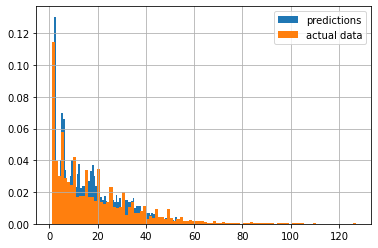

<IPython.core.display.Javascript object>

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)

_ = ax.hist(
    gridsearch.best_estimator_.predict(X_test),
    bins=100,
    label="predictions",
    density=True,
)
df_test["count"].hist(bins=100, label="actual data", density=True)
ax.legend()

It's also useful to visually compare the predicted values with the observed values for different neighborhoods,

In [38]:
df_viz = df_test.copy()
df_viz["count_pred"] = est_gb.predict(X_test)

<IPython.core.display.Javascript object>

/home/rth/miniconda3/envs/predicting-safety-events/lib/python3.8/site-packages/pandas/plotting/_matplotlib/tools.py:30: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 
  fig.subplots_adjust(bottom=0.2)


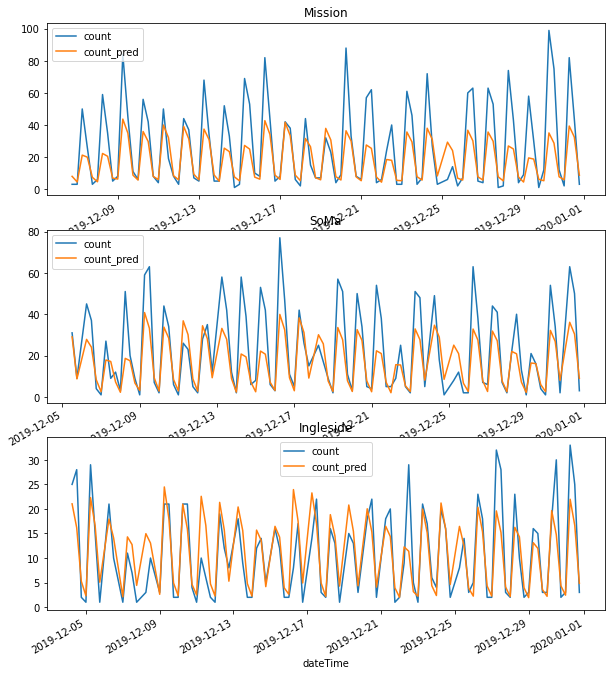

<IPython.core.display.Javascript object>

In [39]:
fig, ax = plt.subplots(3, 1, figsize=(10, 12), constrained_layout=True)


for idx, neighborhood in enumerate(['Mission', 'SoMa', 'Ingleside']):

    mask = df_viz['neighborhood'] == neighborhood

    df_viz[mask].tail(100).plot(
        ax=ax[idx], x='dateTime', y=['count', 'count_pred']
    )
    ax[idx].set_title(neighborhood)


We reproduce the weekly periodicity and trends, however there is a significant
day to day variance that still isn't accounted for by the model.

## 4. Other attempted approaches

Following approaches were attempted but did not yield a measurable improvement in results,
- applying a transformation to the target variable with [`TransformedTargetRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html) to make its distribution closer to the Normal distribution. Note that when using `HistGradientBoostingRegressor(loss="poisson")` a [log link](https://en.wikipedia.org/wiki/Generalized_linear_model#Link_function) is used internally.
- weight more recent observations higher during training using exponentially decreasing `sample_weight`.

## Conclusion

We have explored several approaches for improving the predictions, randing from using external datasets to searching optimal hyper-parameters. To explore, we could also try a purely time series based approach with for instance the [fb-prothet](https://facebook.github.io/prophet/) package.

In the following milestone we will see try to make the current model more interpretable and evaluate the possibility of bias.